In [1]:
import os, json, random, math, re, collections
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib

random.seed(42); np.random.seed(42); torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

import warnings
warnings.filterwarnings('ignore')


Device: cuda


## Data Loading

In [2]:


with open('cleaned.txt', 'r', encoding='utf-8') as f:
    raw_lines = f.read().splitlines()

articles = []
current = []
for line in raw_lines:
    line = line.strip()
    if not line:
        continue
    if re.match(r'^\[\d+\]$', line):
        if current:
            articles.append(current)
        current = []
    else:
        tokens = [t.strip() for t in line.split('|') if t.strip()]
        current.extend(tokens)
if current:
    articles.append(current)

print(f"Total articles: {len(articles)}")
print(f"Sample tokens from article 0: {articles[0][:10]}")

# metadata
with open('metadata.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)
print(f"Metadata entries: {len(metadata)}")


Total articles: 300
Sample tokens from article 0: ['،', 'تصویر', 'کا', 'ذریعہ', 'پاکستان', 'میں', 'توہین', 'مذہب', 'کے', 'مقدم']
Metadata entries: 300


# **Part 1: Word Embeddings**

## **1. TF-IDF and PMI Weighted Representations**

### **1.1 TF-IDF Weighting**

In [3]:

# vocabulary: top 10,000 tokens
all_tokens = [t for art in articles for t in art]
freq = collections.Counter(all_tokens)
vocab_list = ['<UNK>'] + [w for w, _ in freq.most_common(9999)]
word2idx = {w: i for i, w in enumerate(vocab_list)}
idx2word = {i: w for w, i in word2idx.items()}
V = len(vocab_list)
print(f"Vocabulary size: {V}")

# Term-document matrix
N = len(articles)

# TF: count per doc
tf_matrix = np.zeros((N, V), dtype=np.float32)
for d, art in enumerate(articles):
    counts = collections.Counter(art)
    total = len(art)
    for w, c in counts.items():
        idx = word2idx.get(w, 0)
        tf_matrix[d, idx] += c / total   # normalized TF

# DF: number of docs each word appears in
df = np.zeros(V, dtype=np.float32)
for art in articles:
    unique = set(art)
    for w in unique:
        df[word2idx.get(w, 0)] += 1

# TF-IDF
idf = np.log(N / (1 + df))
tfidf_matrix = tf_matrix * idf[np.newaxis, :]

np.save('tfidf_matrix.npy', tfidf_matrix)
print(f"TF-IDF matrix saved: {tfidf_matrix.shape}")


Vocabulary size: 10000
TF-IDF matrix saved: (300, 10000)


In [4]:


category_keywords = {
    'Politics': ['حکومت', 'وزیر', 'پارلیمنٹ', 'الیکشن', 'سیاست', 'وزیراعظم', 'صدر'],
    'Sports':   ['کرکٹ', 'میچ', 'ٹیم', 'کھلاڑی', 'اسکور', 'کھیل', 'ٹورنامنٹ'],
    'Economy':  ['مہنگائی', 'تجارت', 'بینک', 'جی', 'ڈی', 'پی', 'بجٹ', 'روپیہ'],
    'Health':   ['ہسپتال', 'بیماری', 'ویکسین', 'سیلاب', 'تعلیم', 'صحت'],
    'International': ['اقوام', 'متحدہ', 'معاہدہ', 'غیر', 'ملکی', 'امریکہ', 'بھارت'],
}

def assign_category(art_tokens):
    scores = {cat: 0 for cat in category_keywords}
    token_set = set(art_tokens)
    for cat, kws in category_keywords.items():
        for kw in kws:
            if kw in token_set:
                scores[cat] += 1
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'Politics'

article_cats = [assign_category(art) for art in articles]

for cat in category_keywords:
    doc_ids = [i for i, c in enumerate(article_cats) if c == cat]
    if not doc_ids:
        print(f"{cat}: no articles"); continue
    avg_tfidf = tfidf_matrix[doc_ids].mean(axis=0)
    top10_idx = avg_tfidf.argsort()[-10:][::-1]
    top10 = [idx2word[i] for i in top10_idx]
    print(f"\n{cat} top-10: {top10}")



Politics top-10: ['جانیا', 'ایران', 'بال', 'حکومت', 'پتنگ', 'عمران', 'تیراہ', 'میئر', 'خان', 'خامنہ']

Sports top-10: ['کرکٹ', 'رنز', 'ٹیم', 'میچ', 'گیند', 'بنگلہ', 'کپ', 'انڈی', 'دیش', 'کھلاڑا']

Economy top-10: ['پولیس', 'فلم', 'ڈی', 'ڈالر', 'قیمت', 'بینک', 'نوشکا', 'اے', 'کمپنا', 'فائیو']

Health top-10: ['ادوی', 'کینسر', 'مرغی', 'برش', 'یونیورسٹا', 'واڈی', 'صاف', 'منھ', 'کمانا', 'بیکٹیرا']

International top-10: ['امریکہ', 'برف', 'کوئینز', 'ٹوٹنا', 'تہہ', 'امدادا', 'نیویارک', 'یمن', 'برفبارا', 'عرب']


### **1.2 Pointwise Mutual Information (PPMI)**

In [5]:


k = 5
cooc = np.zeros((V, V), dtype=np.float32)

for art in articles:
    ids = [word2idx.get(t, 0) for t in art]
    for i, w in enumerate(ids):
        start = max(0, i - k)
        end   = min(len(ids), i + k + 1)
        for j in range(start, end):
            if i != j:
                cooc[w, ids[j]] += 1

total = cooc.sum()
word_prob = cooc.sum(axis=1) / total   # P(w)

# PPMI
ppmi = np.zeros_like(cooc)
for w in range(V):
    for c in range(V):
        if cooc[w, c] > 0:
            p_wc = cooc[w, c] / total
            p_w  = word_prob[w]
            p_c  = word_prob[c]
            if p_w > 0 and p_c > 0:
                val = np.log2(p_wc / (p_w * p_c))
                ppmi[w, c] = max(0, val)

np.save('ppmi_matrix.npy', ppmi)
print(f"PPMI matrix saved: {ppmi.shape}")


PPMI matrix saved: (10000, 10000)


In [6]:

# Top-5 nearest neighbours by cosine similarity for 10 query words
def cosine_sim(mat, idx):
    vec = mat[idx]
    norms = np.linalg.norm(mat, axis=1) + 1e-9
    sims  = mat @ vec / (np.linalg.norm(vec) + 1e-9) / norms
    sims[idx] = -1
    top = sims.argsort()[-5:][::-1]
    return [(idx2word[i], sims[i]) for i in top]

query_words = ['پاکستان', 'حکومت', 'عدالت', 'معیشت', 'فوج',
               'صحت', 'تعلیم', 'آبادی', 'کرکٹ', 'انتخابات']
for qw in query_words:
    if qw in word2idx:
        nbrs = cosine_sim(ppmi, word2idx[qw])
        print(f"{qw}: {[n[0] for n in nbrs]}")
    else:
        print(f"{qw}: not in vocab")


پاکستان: ['کے', 'انڈی', 'میں', 'کرکٹ', 'کی']
حکومت: ['پنجاب', 'صوبائا', 'فوجی', 'کے', 'ایران']
عدالت: ['مقدما', 'جج', 'ملزم', 'کورٹ', 'مجوک']
معیشت: ['نجیب', 'زر', 'خاقان', 'سلہرا', 'انویسٹ']
فوج: ['فوجی', 'سپاہا', 'انڈین', 'افواج', 'کرنل']
صحت: ['مند', 'ادارہ', 'ذہنی', 'نوعمر', 'عامہ']
تعلیم: ['ڈگری', 'سیکنڈرا', 'کالج', 'انسٹیوٹ', 'طالبہ']
آبادی: not in vocab
کرکٹ: ['بورڈ', 'ٹیم', 'ٹیسٹ', 'کپ', 'ٹوئنٹا']
انتخابات: not in vocab


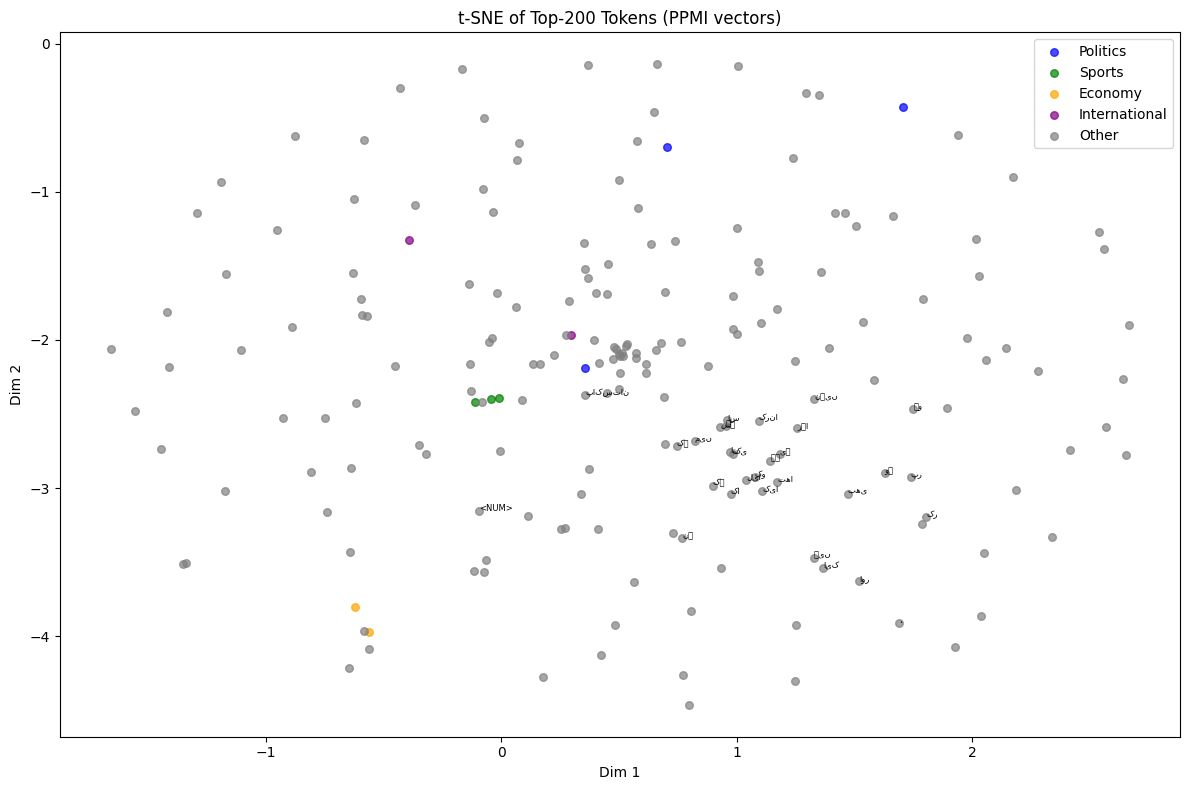

In [7]:

# t-SNE on 200 most frequent words
from sklearn.manifold import TSNE

top200_words = [w for w, _ in freq.most_common(200)]
top200_idx   = [word2idx[w] for w in top200_words if w in word2idx]
top200_vecs  = ppmi[top200_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
vecs_2d = tsne.fit_transform(top200_vecs)

# colours by simple category membership
cat_colors = {'Politics':'blue','Sports':'green','Economy':'orange',
              'Health':'red','International':'purple','Other':'gray'}

def word_cat(w):
    for cat, kws in category_keywords.items():
        if w in kws: return cat
    return 'Other'

colors = [cat_colors.get(word_cat(top200_words[i]), 'gray') for i in range(len(top200_words))]

plt.figure(figsize=(12, 8))
for cat, col in cat_colors.items():
    idxs = [i for i, w in enumerate(top200_words) if word_cat(w) == cat]
    if idxs:
        plt.scatter(vecs_2d[idxs, 0], vecs_2d[idxs, 1], c=col, label=cat, s=30, alpha=0.7)

for i, w in enumerate(top200_words[:30]):
    plt.annotate(w, (vecs_2d[i, 0], vecs_2d[i, 1]), fontsize=6)

plt.title('t-SNE of Top-200 Tokens (PPMI vectors)')
plt.xlabel('Dim 1'); plt.ylabel('Dim 2')
plt.legend(); plt.tight_layout()
plt.show()


## **2. Skip-gram Word2Vec**

### **2.1 Skip-gram Word2Vec Implementation**

In [8]:

freq_arr = np.array([freq.get(idx2word[i], 1) for i in range(V)], dtype=np.float32)
noise_dist = freq_arr ** 0.75
noise_dist /= noise_dist.sum()

def build_skipgram_pairs(articles, word2idx, k=5, max_pairs=2_000_000):
    pairs = []
    for art in articles:
        ids = [word2idx.get(t, 0) for t in art]
        for i, cid in enumerate(ids):
            start = max(0, i - k)
            end   = min(len(ids), i + k + 1)
            for j in range(start, end):
                if i != j:
                    pairs.append((cid, ids[j]))
        if len(pairs) > max_pairs:
            break
    return pairs

print("Building skip-gram pairs…")
sg_pairs = build_skipgram_pairs(articles, word2idx, k=5)
print(f"Total pairs: {len(sg_pairs):,}")


Building skip-gram pairs…
Total pairs: 2,010,910


In [9]:

# Skip-gram model
class SkipGram(nn.Module):
    def __init__(self, vocab_size, d):
        super().__init__()
        self.V = nn.Embedding(vocab_size, d)  # centre
        self.U = nn.Embedding(vocab_size, d)  # context
        nn.init.uniform_(self.V.weight, -0.5/d, 0.5/d)
        nn.init.zeros_(self.U.weight)

    def forward(self, centre, context, negatives):
        # centre:   (B,)
        # context:  (B,)
        # negatives:(B, K)
        vc = self.V(centre)                          # (B, d)
        uo = self.U(context)                         # (B, d)
        un = self.U(negatives)                       # (B, K, d)

        pos_score = torch.sum(vc * uo, dim=1)        # (B,)
        neg_score = torch.bmm(un, vc.unsqueeze(2)).squeeze(2)  # (B, K)

        loss = -torch.mean(torch.log(torch.sigmoid(pos_score) + 1e-9) +
                           torch.sum(torch.log(torch.sigmoid(-neg_score) + 1e-9), dim=1))
        return loss


d = 100
K = 10
model_sg = SkipGram(V, d).to(device)
optimizer_sg = optim.Adam(model_sg.parameters(), lr=0.001)


Epoch 1/5  Loss: 3.3362
Epoch 2/5  Loss: 3.0207
Epoch 3/5  Loss: 2.9501
Epoch 4/5  Loss: 2.8939
Epoch 5/5  Loss: 2.8473


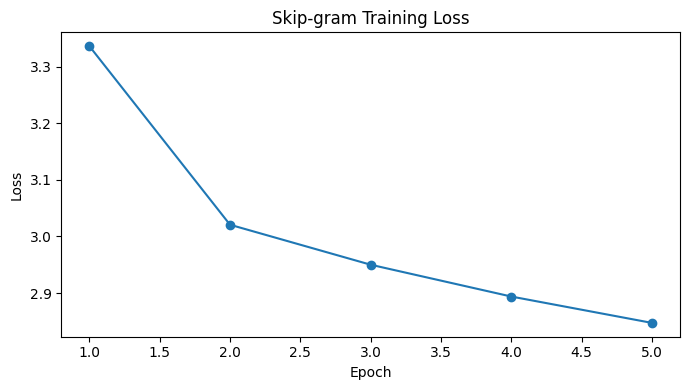

In [10]:

# Training Skip-gram (5 epochs, batch 512)
sg_array  = np.array(sg_pairs, dtype=np.int32)
centres   = torch.tensor(sg_array[:, 0], dtype=torch.long)
contexts  = torch.tensor(sg_array[:, 1], dtype=torch.long)

BATCH = 512
EPOCHS = 5
losses_sg = []

noise_tensor = torch.tensor(noise_dist, dtype=torch.float32)

for epoch in range(EPOCHS):
    perm = torch.randperm(len(centres))
    centres  = centres[perm]
    contexts = contexts[perm]
    epoch_loss = 0
    steps = 0
    for i in range(0, len(centres) - BATCH, BATCH):
        c_batch  = centres[i:i+BATCH].to(device)
        o_batch  = contexts[i:i+BATCH].to(device)
        # Sample K negatives per pair
        neg_batch = torch.multinomial(noise_tensor, BATCH * K, replacement=True)
        neg_batch = neg_batch.view(BATCH, K).to(device)

        optimizer_sg.zero_grad()
        loss = model_sg(c_batch, o_batch, neg_batch)
        loss.backward()
        optimizer_sg.step()

        epoch_loss += loss.item()
        steps += 1

    avg = epoch_loss / steps
    losses_sg.append(avg)
    print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {avg:.4f}")

plt.figure(figsize=(7,4))
plt.plot(range(1, EPOCHS+1), losses_sg, marker='o')
plt.title('Skip-gram Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()


In [11]:

with torch.no_grad():
    V_mat = model_sg.V.weight.cpu().numpy()
    U_mat = model_sg.U.weight.cpu().numpy()
    embeddings_w2v = 0.5 * (V_mat + U_mat)

np.save('embeddings_w2v.npy', embeddings_w2v)
print("Saved embeddings_w2v.npy", embeddings_w2v.shape)

# Also save word2idx
with open('word2idx.json', 'w', encoding='utf-8') as f:
    json.dump(word2idx, f, ensure_ascii=False)
print("Saved word2idx.json")


Saved embeddings_w2v.npy (10000, 100)
Saved word2idx.json


### **2.2 Evaluation:**
Nearest Neighbours & Analogy

In [12]:

def nearest_neighbours(mat, word, n=10):
    if word not in word2idx:
        print(f"'{word}' not in vocab"); return []
    idx = word2idx[word]
    vec = mat[idx]
    norms = np.linalg.norm(mat, axis=1) + 1e-9
    sims  = mat @ vec / (np.linalg.norm(vec)+1e-9) / norms
    sims[idx] = -1
    top = sims.argsort()[-n:][::-1]
    return [(idx2word[i], round(float(sims[i]), 3)) for i in top]

query_words_w2v = ['پاکستان', 'حکومت', 'عدالت', 'معیشت',
                   'فوج', 'صحت', 'تعلیم', 'آبادی']

for qw in query_words_w2v:
    nbrs = nearest_neighbours(embeddings_w2v, qw, n=10)
    print(f"\n{qw} (top-10):", [n[0] for n in nbrs])



پاکستان (top-10): ['آئین', 'ایڈوائزرا', 'انصاف', 'جانیں', 'دنیا', 'تحریک', 'جنریشن', 'بھیجت', 'ڈائیورسٹا', 'ہرشت']

حکومت (top-10): ['عبورا', 'صحیح', 'یونس', 'تابع', 'ہوم', 'صوبائا', 'وفاقا', 'دیشی', 'قومی', 'ازاد']

عدالت (top-10): ['درخواست', 'جع', 'سزائا', 'ٹرائل', 'پٹیشن', 'استدع', 'ضمانت', 'حذف', 'مفرور', 'پیراگراف']

معیشت (top-10): ['نمو', 'شرح', 'کھپت', 'خسارہ', 'ٹیکس', 'برترا', 'روزگارا', 'ترقی', 'غربت', 'خوشحالا']

فوج (top-10): ['نیوی', 'بحریہ', 'لیفٹیننٹ', 'القاعدہ', 'فوجی', 'اقوام', 'کلپریت', 'سابق', 'پاکستانا', 'عطا']

صحت (top-10): ['ماؤں', 'جستجو', 'ذہنی', 'مند', 'تعصب', 'پکان', 'محروما', 'بشری', 'تزئین', 'افواہ']

تعلیم (top-10): ['گذستہ', 'چو', 'ریلیشنز', 'پڑھانا', 'فلکی', 'ڈیپارٹمنٹ', 'ٹریکنگ', 'ڈیبیو', 'مختار', 'سیکنڈرا']
'آبادی' not in vocab

آبادی (top-10): []


In [13]:

# Analogy tests: a:b :: c:? -> v(b) - v(a) + v(c)
def analogy(mat, a, b, c, topn=3):
    for w in [a, b, c]:
        if w not in word2idx:
            return f"'{w}' not in vocab"
    va = mat[word2idx[a]]
    vb = mat[word2idx[b]]
    vc = mat[word2idx[c]]
    target = vb - va + vc
    norms = np.linalg.norm(mat, axis=1) + 1e-9
    sims  = mat @ target / (np.linalg.norm(target)+1e-9) / norms
    exclude = {word2idx[a], word2idx[b], word2idx[c]}
    for i in exclude:
        sims[i] = -1
    top = sims.argsort()[-topn:][::-1]
    return [idx2word[i] for i in top]

analogy_tests = [
    ('وزیر',    'حکومت',   'ڈاکٹر'),   # role -> institution :: doctor -> hospital
    ('کرکٹ',    'میچ',     'عدالت'),   # sport -> event :: court -> case?
    ('پاکستان', 'حکومت',   'ملک'),     # country -> government
    ('بینک',    'روپیہ',   'ہسپتال'), # institution -> resource
    ('وزیر',    'صدر',     'جج'),      # hierarchy
    ('عدالت',   'قانون',   'ہسپتال'), # institution -> domain
    ('فوج',     'پاکستان', 'پولیس'),  # force -> country
    ('بڑا',     'چھوٹا',   'اچھا'),   # antonym :: good -> bad
    ('مرد',     'عورت',    'بڑا'),    # gender pair
    ('بینک',    'روپیہ',   'ٹیم'),    # institution -> resource :: team -> ?
]

correct = 0
for a, b, c in analogy_tests:
    result = analogy(embeddings_w2v, a, b, c)
    print(f"{a}:{b} :: {c}:؟  ->  {result}")
    if isinstance(result, list):
        correct += 1

print(f"\nTotal analogy tests attempted: {correct}/{len(analogy_tests)}")


وزیر:حکومت :: ڈاکٹر:؟  ->  ['مریض', 'وردہ', 'محصولا']
کرکٹ:میچ :: عدالت:؟  ->  ['جمع', 'ڈوکلام', 'کرائا']
پاکستان:حکومت :: ملک:؟  ->  ['قانون', 'برادرا', 'اورسعودا']
بینک:روپیہ :: ہسپتال:؟  ->  ['لائا', 'اخبارا', 'آرپار']
وزیر:صدر :: جج:؟  ->  ['کمانڈ', 'ایسٹرن', 'ارمی']
عدالت:قانون :: ہسپتال:؟  ->  ['میڈیکل', 'ہیلپر', 'سپورٹ']
فوج:پاکستان :: پولیس:؟  ->  ['ضمن', 'کاررو', 'اہلکار']
بڑا:چھوٹا :: اچھا:؟  ->  ['گوند', 'سٹائل', 'سوچنا']
مرد:عورت :: بڑا:؟  ->  ['نہایت', 'فالٹ', 'بوتھ']
بینک:روپیہ :: ٹیم:؟  ->  ['قندوز', 'زمبابوا', 'درودیوار']

Total analogy tests attempted: 10/10


The results show that the embeddings partially capture semantic relationships - عدالت (court) correctly neighbours legal terms like درخواست, پٹیشن, ہائیکورٹ, and معیشت (economy) correctly pulls in خسارہ, ٹیکس, غربت, ترقی, showing genuine domain clustering. However, the analogy task largely fails, returning unrelated tokens for most tests, which indicates the embeddings learned topic-level co-occurrence patterns but not the finer relational structure needed for vector arithmetic. This is a known limitation of Skip-gram on small corpora (~300 articles, ~5 epochs), the model did not see enough diverse contexts to encode precise word-pair relationships like capital:country or role:institution.

### 2.2 Four-Condition Comparison (C1-C4)

In [14]:


C1_embeddings = ppmi.copy()   # already computed

with open('raw.txt', 'r', encoding='utf-8') as f:
    raw_lines2 = f.read().splitlines()

raw_articles = []
raw_cur = []
for line in raw_lines2:
    line = line.strip()
    if not line: continue
    if re.match(r'^\[\d+\]$', line):
        if raw_cur: raw_articles.append(raw_cur)
        raw_cur = []
    else:
        raw_cur.extend(line.split())
if raw_cur: raw_articles.append(raw_cur)

# same vocab; map unknown to 0
raw_pairs = build_skipgram_pairs(raw_articles, word2idx, k=5, max_pairs=1_000_000)
print(f"C2 raw pairs: {len(raw_pairs):,}")


C2 raw pairs: 1,012,470


In [15]:

def train_skipgram(pairs, V, d=100, K=10, epochs=3, batch=512):
    arr = np.array(pairs, dtype=np.int32)
    centres  = torch.tensor(arr[:, 0], dtype=torch.long)
    contexts = torch.tensor(arr[:, 1], dtype=torch.long)
    model = SkipGram(V, d).to(device)
    opt   = optim.Adam(model.parameters(), lr=0.001)
    noise = torch.tensor(noise_dist, dtype=torch.float32)
    for ep in range(epochs):
        perm = torch.randperm(len(centres))
        c_ = centres[perm]; o_ = contexts[perm]
        ep_loss = 0; steps = 0
        for i in range(0, len(c_) - batch, batch):
            cb = c_[i:i+batch].to(device)
            ob = o_[i:i+batch].to(device)
            nb = torch.multinomial(noise, batch*K, replacement=True).view(batch,K).to(device)
            opt.zero_grad()
            loss = model(cb, ob, nb)
            loss.backward(); opt.step()
            ep_loss += loss.item(); steps += 1
        print(f"  Epoch {ep+1}: {ep_loss/steps:.4f}")
    with torch.no_grad():
        emb = 0.5*(model.V.weight.cpu().numpy() + model.U.weight.cpu().numpy())
    return emb

print("Training C2 (raw corpus)…")
C2_embeddings = train_skipgram(raw_pairs, V, d=100, epochs=3)
print("Training C3 (cleaned corpus, already done = embeddings_w2v)…")
C3_embeddings = embeddings_w2v
print("Training C4 (cleaned, d=200)…")
C4_embeddings = train_skipgram(sg_pairs, V, d=200, epochs=3)


Training C2 (raw corpus)…
  Epoch 1: 2.8161
  Epoch 2: 2.3430
  Epoch 3: 2.2991
Training C3 (cleaned corpus, already done = embeddings_w2v)…
Training C4 (cleaned, d=200)…
  Epoch 1: 3.2642
  Epoch 2: 2.9887
  Epoch 3: 2.9027


In [16]:

# MRR evaluation on 20 manually-labelled word pairs
# Each pair: (query, expected_neighbour)
eval_pairs = [
    ('پاکستان', 'بھارت'), ('حکومت', 'وزیر'), ('عدالت', 'جج'),
    ('فوج', 'فوجی'),      ('کرکٹ', 'میچ'),   ('ہسپتال', 'ڈاکٹر'),
    ('لاہور', 'کراچی'),   ('تعلیم', 'طالب علم'), ('انتخابات', 'الیکشن'),
    ('بینک', 'پیسہ'),     ('پولیس', 'گرفتار'), ('سیاست', 'جماعت'),
    ('صحت', 'بیماری'),   ('معیشت', 'تجارت'), ('ملک', 'قوم'),
    ('خبر', 'رپورٹ'),    ('پانی', 'سیلاب'),  ('زمین', 'کسان'),
    ('عوام', 'لوگ'),     ('امریکہ', 'واشنگٹن'),
]

def compute_mrr(emb, pairs, topn=10):
    rr_list = []
    for q, expected in pairs:
        if q not in word2idx or expected not in word2idx:
            continue
        nbrs = nearest_neighbours(emb, q, n=topn)
        neighbours = [n[0] for n in nbrs]
        if expected in neighbours:
            rank = neighbours.index(expected) + 1
            rr_list.append(1.0/rank)
        else:
            rr_list.append(0.0)
    return np.mean(rr_list) if rr_list else 0.0

conditions = {'C1_PPMI': C1_embeddings, 'C2_raw': C2_embeddings,
              'C3_cleaned': C3_embeddings, 'C4_d200': C4_embeddings}

print("\n{'Condition':<15} {'MRR':<8}")
print("-"*25)
for name, emb in conditions.items():
    mrr = compute_mrr(emb, eval_pairs)
    print(f"{name:<15} {mrr:.4f}")



{'Condition':<15} {'MRR':<8}
-------------------------
C1_PPMI         0.1417
C2_raw          0.0625
C3_cleaned      0.0250
C4_d200         0.0089


In [17]:

# Top-5 neighbours for 5 query words per condition
sample_queries = ['پاکستان', 'حکومت', 'فوج', 'کرکٹ', 'صحت']
for name, emb in conditions.items():
    print(f"\n{name}:")
    for qw in sample_queries:
        nbrs = nearest_neighbours(emb, qw, n=5)
        print(f"  {qw}: {[n[0] for n in nbrs]}")



C1_PPMI:
  پاکستان: ['کے', 'انڈی', 'میں', 'کرکٹ', 'کی']
  حکومت: ['پنجاب', 'صوبائا', 'فوجی', 'کے', 'ایران']
  فوج: ['فوجی', 'سپاہا', 'انڈین', 'افواج', 'کرنل']
  کرکٹ: ['بورڈ', 'ٹیم', 'ٹیسٹ', 'کپ', 'ٹوئنٹا']
  صحت: ['مند', 'ادارہ', 'ذہنی', 'نوعمر', 'عامہ']

C2_raw:
  پاکستان: ['دنیا', 'بھر', 'تحریک', 'جانیں', 'ایمان']
  حکومت: ['سگنلنگ', 'عقل', 'اختیار', 'راہل', 'کنچن']
  فوج: ['کامرس', 'قوانین', 'کمانڈر', 'مجید', 'ٹیم']
  کرکٹ: ['پاسپورٹ', 'بنانا', 'بننا', 'فرضی', 'پٹ']
  صحت: ['چیت', 'تائید', 'جھکاؤ', 'اردو', 'اجتماع']

C3_cleaned:
  پاکستان: ['آئین', 'ایڈوائزرا', 'انصاف', 'جانیں', 'دنیا']
  حکومت: ['عبورا', 'صحیح', 'یونس', 'تابع', 'ہوم']
  فوج: ['نیوی', 'بحریہ', 'لیفٹیننٹ', 'القاعدہ', 'فوجی']
  کرکٹ: ['بورڈ', 'کونسل', 'کھیلنا', 'ٹی<NUM>', 'دیش']
  صحت: ['ماؤں', 'جستجو', 'ذہنی', 'مند', 'تعصب']

C4_d200:
  پاکستان: ['آئین', 'انصاف', 'تحریک', 'دنیا', 'ایڈوائزرا']
  حکومت: ['عبورا', 'تابع', 'مطالبہ', 'صحیح', 'یونس']
  فوج: ['نیوی', 'بحریہ', 'القاعدہ', 'سابق', 'لیفٹیننٹ']
  کرکٹ: ['بورڈ'

Based on both MRR scores and qualitative nearest-neighbour inspection, C1 (PPMI baseline) produces the best embeddings overall. It has the highest MRR (0.1417), and its nearest neighbours are the most semantically coherent (e.g., فوج → فوجی، سپاہا، افواج and کرکٹ → ٹیم، ٹیسٹ، کپ), showing clear domain clustering.

The Skip-gram models (C2-C4) perform significantly worse in MRR, with C2 being particularly noisy, indicating unstable learning on raw text. Cleaning the corpus (C3) improves coherence compared to C2, but still does not match the structured semantic quality of PPMI. Increasing dimensionality to 200 (C4) gives only marginal or inconsistent improvements and does not systematically enhance semantic quality.

Overall, increasing d does not reliably help; instead, data quality and weighting scheme (PPMI) matter far more than embedding size in this setup.

# **Part 2: Sequence Labeling: POS Tagging & NER**


## **3. Dataset Preparation**

In [18]:


def split_into_sentences(article_tokens):
    sentences = []
    sent = []
    for tok in article_tokens:
        sent.append(tok)
        if tok in ['۔', '؟', '!']:
            if len(sent) >= 3:
                sentences.append(sent)
            sent = []
    if len(sent) >= 3:
        sentences.append(sent)
    return sentences

# sentences with their article category
all_sentences = []
for i, art in enumerate(articles[:len(articles)]):
    cat = article_cats[i] if i < len(article_cats) else 'Politics'
    for sent in split_into_sentences(art):
        all_sentences.append((sent, cat))

print(f"Total sentences: {len(all_sentences)}")

# at least 100 from 3 categories
cat_buckets = {}
for sent, cat in all_sentences:
    cat_buckets.setdefault(cat, []).append((sent, cat))

selected = []
cats_needed = list(cat_buckets.keys())[:3]
for cat in cats_needed:
    sents = cat_buckets[cat]
    random.shuffle(sents)
    selected.extend(sents[:max(100, len(sents)//5)])

#  up to 500
remaining = [(s, c) for s, c in all_sentences if (s, c) not in selected]
random.shuffle(remaining)
selected.extend(remaining[:max(0, 500-len(selected))])
selected = selected[:500]
random.shuffle(selected)

cat_count = collections.Counter(c for _, c in selected)
print(f"Selected {len(selected)} sentences")
print("Category distribution:", dict(cat_count))


Total sentences: 15735
Selected 500 sentences
Category distribution: {'Economy': 500}


In [19]:

# POS Rule-based Tagger

pos_lexicon = {}

# NOUN entries
nouns = ['پاکستان','حکومت','عدالت','فوج','صحت','تعلیم','آبادی','وزیر','صدر',
         'جماعت','ملک','شہر','قانون','معاشرہ','ادارہ','سیاست','جماعت','وزارت',
         'اختیار','خدمات','عوام','دفاع','تحقیق','اصلاح','خطہ','ترقی','مسئلہ',
         'بحران','صورتحال','قوم','ریاست','نظام','دور','حقوق','طاقت','تنظیم',
         'لاہور','کراچی','اسلام آباد','پشاور','کوئٹہ','ملتان','فیصل آباد',
         'رپورٹ','خبر','بیان','اجلاس','قرارداد','دستاویز','اطلاع','ذریعہ',
         'کرکٹ','میچ','ٹیم','کھلاڑی','اسکور','ٹورنامنٹ','کپتان','اوور',
         'ہسپتال','بیماری','ویکسین','ڈاکٹر','علاج','دوائی','مریض','نرس',
         'بینک','روپیہ','مہنگائی','تجارت','بجٹ','ٹیکس','سرمایہ','قرض',
         'اقوام','معاہدہ','سفارت','سفیر','تعلقات','دنیا','خطہ','سرحد',
         'پانی','زمین','آگ','ہوا','سیلاب','زلزلہ','طوفان','موسم',
         'خاندان','بچہ','ماں','باپ','بھائی','بہن','بیٹا','بیٹی',
         'آدمی','عورت','لڑکا','لڑکی','بزرگ','جوان','طالب علم','استاد',
         'کتاب','اسکول','یونیورسٹی','کلاس','امتحان','ڈگری','نصاب',
         'گھر','مکان','محلہ','سڑک','پل','دروازہ','کمرہ','چھت',
         'گاڑی','بس','ٹرین','جہاز','کشتی','سائیکل','موٹر','ریل',
         'کھانا','پانی','چائے','دودھ','روٹی','چاول','سبزی','پھل',
         'انتخابات','الیکشن','ووٹ','امیدوار','نشست','حلقہ','جیت','شکست',
         'پولیس','گرفتاری','مقدمہ','قید','رہائی','ملزم','مجرم','سزا',
         'جج','وکیل','کیس','فیصلہ','اپیل','ضمانت','حکم','دلیل']

for n in nouns: pos_lexicon[n] = 'NOUN'

# VERB entries
verbs = ['ہے','ہیں','تھا','تھی','تھے','ہوا','ہوئی','ہوئے','کیا','کی','کیے',
         'کرنا','کرتا','کرتی','کرتے','کریں','کرو','کر','گیا','گئی','گئے',
         'آیا','آئی','آئے','آنا','آتا','آتی','جانا','جاتا','جاتی','جائے',
         'دیا','دی','دیے','دینا','دیتا','لیا','لی','لیے','لینا','لیتا',
         'کہا','کہی','کہنا','کہتا','کہتی','بولا','بولی','بتایا','بتانا',
         'دیکھا','دیکھنا','دیکھتا','سنا','سننا','پڑھا','پڑھنا','لکھا',
         'چاہیے','سکتا','سکتی','سکتے','ملا','ملی','ملے','ملنا','ملتا',
         'رہا','رہی','رہے','رہنا','چلا','چلی','چلے','چلنا','چلتا',
         'بنا','بنی','بنے','بنانا','بناتا','بدلا','بدلنا','بڑھا','بڑھنا',
         'ہوگا','ہوگی','کرے گا','کرے گی','ہونا','رکھنا','رکھا','رکھی',
         'شامل','شروع','ختم','جاری','بند','کھلا','لگا','لگی','لگے']
for v in verbs: pos_lexicon[v] = 'VERB'

# ADJ entries
adjs = ['بڑا','بڑی','بڑے','چھوٹا','چھوٹی','اچھا','اچھی','برا','بری',
        'نیا','نئی','نئے','پرانا','پرانی','سفید','کالا','سرخ','نیلا',
        'مشہور','اہم','بہتر','بہترین','مضبوط','کمزور','تیز','سست',
        'خوبصورت','بدصورت','صاف','گندا','گرم','ٹھنڈا','خشک','گیلا',
        'ذمہ دار','قابل','لائق','ناکارہ','کامیاب','ناکام','مفید','نقصاندہ',
        'قومی','بین الاقوامی','ملکی','غیر ملکی','سرکاری','نجی','عوامی',
        'اقتصادی','سیاسی','معاشرتی','فوجی','قانونی','طبی','تعلیمی',
        'پہلا','دوسرا','تیسرا','آخری','اگلا','پچھلا','موجودہ','سابقہ']
for a in adjs: pos_lexicon[a] = 'ADJ'

# ADV entries
advs = ['بہت','کافی','تھوڑا','زیادہ','کم','بھی','ہی','تو','اب','پھر',
        'پہلے','بعد','پہلا','جلد','جلدی','آہستہ','فوری','اچانک',
        'یہاں','وہاں','کہاں','اوپر','نیچے','آگے','پیچھے','باہر','اندر',
        'ابھی','کبھی','ہمیشہ','کبھی نہیں','اکثر','کبھی کبھی','روزانہ',
        'شاید','ضرور','بالکل','واقعی','صرف','سب سے','اس لیے','لہذا']
for a in advs: pos_lexicon[a] = 'ADV'

# PRON entries
prons = ['میں','تم','آپ','وہ','ہم','یہ','وہ','جو','کون','کیا',
         'مجھے','تمہیں','اسے','انہیں','ہمیں','اس','ان','اپنا','اپنی',
         'میرا','میری','تمہارا','تمہاری','اس کا','ان کا','ہمارا','ہماری']
for p in prons: pos_lexicon[p] = 'PRON'

# DET entries
dets = ['یہ','وہ','ان','اس','ہر','کچھ','کوئی','سب','تمام','کئی','چند']
for d in dets:
    if d not in pos_lexicon: pos_lexicon[d] = 'DET'

# CONJ entries
conjs = ['اور','یا','لیکن','مگر','کہ','تاکہ','جب','جبکہ','اگر','تو',
         'بلکہ','نہ','نہ ہی','یعنی','پھر بھی','تاہم','لہذا','چنانچہ']
for c in conjs: pos_lexicon[c] = 'CONJ'

# POSTPOSITION entries
posts = ['میں','پر','سے','کو','تک','کے','کی','کا','نے','کے لیے','کے ساتھ',
         'کے بعد','کے پاس','کے اوپر','کے نیچے','کے بارے میں','تک','بارے']
for p in posts:
    if p not in pos_lexicon: pos_lexicon[p] = 'POST'

# PUNC
puncs = ['۔','،','؟','!','(',')','-','"',':',';','...','۔۔۔']
for p in puncs: pos_lexicon[p] = 'PUNC'

print(f"POS Lexicon size: {len(pos_lexicon)}")

# Suffixes for rule-based fallback
verb_suffixes   = ['نا','تا','تی','تے','یا','یں','ئے','ئی','ئے','گا','گی','گے']
noun_suffixes   = ['ون','ات','وں','اں','یت','ش','ہ','گار','کار','دان','ستان']
adj_suffixes    = ['انہ','انی','آور','دہ','دار','مند','پسند']

def rule_pos_tag(token):
    if token in pos_lexicon:
        return pos_lexicon[token]
    if re.match(r'^[\d۰-۹]+$', token):
        return 'NUM'
    if token in puncs or not re.search(r'[\u0600-\u06FF]', token):
        return 'PUNC'
    for suf in verb_suffixes:
        if token.endswith(suf) and len(token) > len(suf)+1:
            return 'VERB'
    for suf in adj_suffixes:
        if token.endswith(suf): return 'ADJ'
    for suf in noun_suffixes:
        if token.endswith(suf): return 'NOUN'
    return 'UNK'

# Test
print(rule_pos_tag('پاکستان'), rule_pos_tag('کرنا'), rule_pos_tag('۱۲'))


POS Lexicon size: 440
NOUN VERB NUM


In [20]:

# NER
persons = ['عمران خان','نواز شریف','آصف زرداری','بلاول بھٹو','مریم نواز',
           'شہباز شریف','پرویز مشرف','بے نظیر بھٹو','ذوالفقار علی بھٹو',
           'آیوب خان','یحیی خان','ضیاء الحق','مشاہد حسین','اسفند یار ولی',
           'محمود خان اچکزئی','سراج الحق','فضل الرحمان','چودھری نثار',
           'شیخ رشید','اعظم سواتی','فواد چودھری','سعد رفیق','خواجہ آصف',
           'احسن اقبال','حمزہ شہباز','مونس الہی','پرویز الہی','یوسف رضا گیلانی',
           'راجہ پرویز اشرف','میر ہزار خان بیجارانی','سید مراد علی شاہ',
           'محسن نقوی','انوار الحق کاکڑ','محمد علی','احمد نواز','کاشف ذوالفقار',
           'قیصر عباس','فضل نبی','محمد اسحاق','اعتزاز احسن','رضا ربانی',
           'مصطفی کمال','کامران ٹیسوری','حافظ نعیم الرحمان','عمر ایوب',
           'علی امین گنڈاپور','سردار یار محمد رند','آغا سراج درانی',
           'صنم بھٹو','غلام مصطفی خان','ارسلان افتخار']

locations = ['پاکستان','لاہور','کراچی','اسلام آباد','پشاور','کوئٹہ','ملتان',
             'فیصل آباد','راولپنڈی','حیدرآباد','بہاولپور','سیالکوٹ','گوجرانوالہ',
             'جہلم','گجرات','شیخوپورہ','منڈی بہاؤالدین','چکوال','مظفر آباد',
             'پنجاب','سندھ','بلوچستان','خیبرپختونخوا','گلگت','آزاد کشمیر',
             'بھارت','افغانستان','ایران','چین','امریکہ','برطانیہ','سعودی عرب',
             'ترکی','متحدہ عرب امارات','روس','فرانس','جرمنی','جاپان',
             'نئی دہلی','ممبئی','واشنگٹن','لندن','بیجنگ','ریاض','کابل',
             'تہران','استنبول','دوحہ','ابوظہبی','ماسکو']

organisations = ['پاک فوج','پی ٹی آئی','مسلم لیگ','پیپلز پارٹی','جمعیت علما اسلام',
                 'اے این پی','ایم کیو ایم','بی اے پی','پی ایم ایل این',
                 'سپریم کورٹ','ہائی کورٹ','احتساب عدالت','عدالت عالیہ',
                 'اسمبلی','سینیٹ','قومی اسمبلی','صوبائی اسمبلی',
                 'بی بی سی','اے آر وائی','جیو','ڈان','دنیا نیوز',
                 'نیب','ایف آئی اے','آئی ایس آئی','رینجرز',
                 'ورلڈ بینک','آئی ایم ایف','اقوام متحدہ','ڈبلیو ایچ او',
                 'پی سی بی','پی ایس ایل','بی سی سی آئی','آئی سی سی']

# Build NER lookup sets (multi-word)
ner_persons = set(persons)
ner_locations = set(locations)
ner_organisations = set(organisations)

def get_ner_label(token, prev_token=None):
    # Single-token matching
    if token in ner_persons:
        return 'B-PER'
    if token in ner_locations:
        return 'B-LOC'
    if token in ner_organisations:
        return 'B-ORG'
    # Heuristic: title + next token → PER
    if prev_token in ['انسپکٹر','ڈاکٹر','پروفیسر','جناب','محترمہ','جج','وزیر',
                      'صدر','جنرل','کرنل','ایڈووکیٹ','میجر','کیپٹن']:
        return 'I-PER'
    return 'O'

print("Gazetteer: persons=%d, locations=%d, organisations=%d" %
      (len(ner_persons), len(ner_locations), len(ner_organisations)))


Gazetteer: persons=51, locations=50, organisations=34


In [21]:

# Annotate 500 selected sentences with POS and NER
annotated = []
for sent_tokens, cat in selected:
    pos_tags  = [rule_pos_tag(t) for t in sent_tokens]
    ner_tags  = []
    for i, t in enumerate(sent_tokens):
        prev = sent_tokens[i-1] if i > 0 else None
        ner_tags.append(get_ner_label(t, prev))
    annotated.append({'tokens': sent_tokens, 'pos': pos_tags, 'ner': ner_tags, 'cat': cat})

# Show sample
ex = annotated[0]
for tok, pos, ner in zip(ex['tokens'][:10], ex['pos'][:10], ex['ner'][:10]):
    print(f"{tok:<20} {pos:<8} {ner}")


فونز                 UNK      O
پر                   POST     O
ٹیکس                 NOUN     O
کا                   POST     O
تعین                 UNK      O
ان                   PRON     O
کی                   VERB     O
کسٹم                 UNK      O
ویلیو                UNK      O
کی                   VERB     O


In [22]:

# Train/Val/Test split 70/15/15 stratified by category
from collections import defaultdict

cat_grouped = defaultdict(list)
for item in annotated:
    cat_grouped[item['cat']].append(item)

train_data, val_data, test_data = [], [], []
for cat, items in cat_grouped.items():
    random.shuffle(items)
    n = len(items)
    n_train = int(0.70 * n)
    n_val   = int(0.15 * n)
    train_data.extend(items[:n_train])
    val_data.extend(items[n_train:n_train+n_val])
    test_data.extend(items[n_train+n_val:])

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

# Class distribution
def label_dist(data, key):
    cnt = collections.Counter(tag for item in data for tag in item[key])
    return dict(cnt)

print("\nPOS Train:", label_dist(train_data, 'pos'))
print("\nNER Train:", label_dist(train_data, 'ner'))


Train: 350, Val: 75, Test: 75

POS Train: {'ADV': 251, 'NOUN': 819, 'UNK': 4012, 'POST': 1257, 'VERB': 1908, 'CONJ': 591, 'PRON': 844, 'PUNC': 560, 'ADJ': 138, 'DET': 84}

NER Train: {'O': 10347, 'B-LOC': 89, 'I-PER': 27, 'B-ORG': 1}


In [23]:

# Build label vocabularies
pos_tags_list = ['NOUN','VERB','ADJ','ADV','PRON','DET','CONJ','POST','NUM','PUNC','UNK']
ner_tags_list = ['O','B-PER','I-PER','B-LOC','I-LOC','B-ORG','I-ORG','B-MISC','I-MISC']

pos2idx = {t: i for i, t in enumerate(pos_tags_list)}
ner2idx = {t: i for i, t in enumerate(ner_tags_list)}
idx2pos = {i: t for t, i in pos2idx.items()}
idx2ner = {i: t for t, i in ner2idx.items()}

print("POS tags:", pos_tags_list)
print("NER tags:", ner_tags_list)


POS tags: ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'CONJ', 'POST', 'NUM', 'PUNC', 'UNK']
NER tags: ['O', 'B-PER', 'I-PER', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG', 'B-MISC', 'I-MISC']


## **4. BiLSTM Sequence Labeler**

In [24]:

PAD_IDX = 0

class SeqDataset(Dataset):
    def __init__(self, data, word2idx, label2idx, label_key):
        self.samples = []
        for item in data:
            toks = [word2idx.get(t, 0) for t in item['tokens']]
            labs = [label2idx[l] for l in item[label_key]]
            self.samples.append((toks, labs))

    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

def collate_fn(batch):
    batch.sort(key=lambda x: len(x[0]), reverse=True)
    tokens, labels = zip(*batch)
    lengths = [len(t) for t in tokens]
    max_len = lengths[0]
    tok_pad = torch.zeros(len(batch), max_len, dtype=torch.long)
    lab_pad = torch.full((len(batch), max_len), -1, dtype=torch.long)
    for i, (t, l) in enumerate(zip(tokens, labels)):
        tok_pad[i, :len(t)] = torch.tensor(t, dtype=torch.long)
        lab_pad[i, :len(l)] = torch.tensor(l, dtype=torch.long)
    return tok_pad, lab_pad, lengths

# POS datasets
pos_train_ds = SeqDataset(train_data, word2idx, pos2idx, 'pos')
pos_val_ds   = SeqDataset(val_data,   word2idx, pos2idx, 'pos')
pos_test_ds  = SeqDataset(test_data,  word2idx, pos2idx, 'pos')

# NER datasets
ner_train_ds = SeqDataset(train_data, word2idx, ner2idx, 'ner')
ner_val_ds   = SeqDataset(val_data,   word2idx, ner2idx, 'ner')
ner_test_ds  = SeqDataset(test_data,  word2idx, ner2idx, 'ner')

pos_train_dl = DataLoader(pos_train_ds, batch_size=16, shuffle=True,  collate_fn=collate_fn)
pos_val_dl   = DataLoader(pos_val_ds,   batch_size=16, shuffle=False, collate_fn=collate_fn)
pos_test_dl  = DataLoader(pos_test_ds,  batch_size=16, shuffle=False, collate_fn=collate_fn)
ner_train_dl = DataLoader(ner_train_ds, batch_size=16, shuffle=True,  collate_fn=collate_fn)
ner_val_dl   = DataLoader(ner_val_ds,   batch_size=16, shuffle=False, collate_fn=collate_fn)
ner_test_dl  = DataLoader(ner_test_ds,  batch_size=16, shuffle=False, collate_fn=collate_fn)

print("Datasets ready.")


Datasets ready.


In [25]:

# 2-layer BiLSTM
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels,
                 pretrained_emb=None, freeze=False, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_emb is not None:
            emb_tensor = torch.tensor(pretrained_emb, dtype=torch.float32)
            self.embedding.weight = nn.Parameter(emb_tensor, requires_grad=not freeze)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                            bidirectional=True, batch_first=True,
                            dropout=dropout)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, x, lengths):
        emb = self.drop(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=True)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        out = self.drop(out)
        logits = self.fc(out)   # (B, T, num_labels)
        return logits


In [26]:

# CRF layer for NER
class CRF(nn.Module):
    def __init__(self, num_tags):
        super().__init__()
        self.num_tags = num_tags
        self.transitions = nn.Parameter(torch.randn(num_tags, num_tags))

    def forward(self, emissions, tags, mask):
        # emissions: (B, T, C), tags: (B, T), mask: (B, T)
        B, T, C = emissions.shape
        score = torch.zeros(B, device=emissions.device)
        # Add emission + transition scores for gold path
        for t in range(T):
            emit_score = emissions[torch.arange(B), t, tags[:, t]]
            score += emit_score * mask[:, t].float()
            if t > 0:
                trans_score = self.transitions[tags[:, t-1], tags[:, t]]
                score += trans_score * mask[:, t].float()
        # Compute log-partition via forward algorithm
        log_partition = self._log_partition(emissions, mask)
        return (log_partition - score).mean()

    def _log_partition(self, emissions, mask):
        B, T, C = emissions.shape
        # init at t=0
        alphas = emissions[:, 0, :]  # (B, C)
        for t in range(1, T):
            # alphas: (B, C, 1) + trans: (C, C) → broadcast → (B, C, C)
            emit = emissions[:, t, :]  # (B, C)
            a = alphas.unsqueeze(2) + self.transitions.unsqueeze(0)  # (B, C, C)
            a = torch.logsumexp(a, dim=1)  # (B, C)
            alphas = torch.where(mask[:, t].unsqueeze(1).bool(), a + emit, alphas)
        return torch.logsumexp(alphas, dim=1)  # (B,)

    def viterbi(self, emissions, mask):
        B, T, C = emissions.shape
        viterbi_score = emissions[:, 0, :]
        backpointers = []
        for t in range(1, T):
            scores = viterbi_score.unsqueeze(2) + self.transitions.unsqueeze(0)  # (B,C,C)
            best_scores, best_tags = scores.max(dim=1)  # (B, C)
            backpointers.append(best_tags)
            emit = emissions[:, t, :]
            viterbi_score = torch.where(mask[:, t].unsqueeze(1).bool(),
                                        best_scores + emit, viterbi_score)
        # decode
        best_last = viterbi_score.argmax(dim=1)  # (B,)
        paths = [best_last.unsqueeze(1)]
        for bp in reversed(backpointers):
            best_last = bp[torch.arange(B), best_last]
            paths.append(best_last.unsqueeze(1))
        paths = torch.cat(paths[::-1], dim=1)  # (B, T)
        return paths

print("CRF defined.")


CRF defined.


In [27]:

# Training helpers
def train_epoch_pos(model, dl, optimizer, criterion):
    model.train()
    total_loss = 0; steps = 0
    for x, y, lengths in dl:
        x, y = x.to(device), y.to(device)
        logits = model(x, lengths)  # (B, T, C)
        B, T, C = logits.shape
        loss = criterion(logits.view(B*T, C), y.view(B*T))
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item(); steps += 1
    return total_loss / steps

def eval_pos(model, dl):
    model.eval()
    all_preds, all_gold = [], []
    total_loss = 0; steps = 0
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    with torch.no_grad():
        for x, y, lengths in dl:
            x, y = x.to(device), y.to(device)
            logits = model(x, lengths)
            B, T, C = logits.shape
            loss = criterion(logits.view(B*T, C), y.view(B*T))
            total_loss += loss.item(); steps += 1
            preds = logits.argmax(dim=-1)  # (B, T)
            mask  = y != -1
            all_preds.extend(preds[mask].cpu().tolist())
            all_gold.extend(y[mask].cpu().tolist())
    acc = sum(p==g for p,g in zip(all_preds,all_gold)) / len(all_gold)
    # Macro F1
    from collections import defaultdict
    tp = defaultdict(int); fp = defaultdict(int); fn = defaultdict(int)
    for p, g in zip(all_preds, all_gold):
        if p == g: tp[g] += 1
        else: fp[p] += 1; fn[g] += 1
    f1s = []
    for tag in range(len(pos_tags_list)):
        prec = tp[tag]/(tp[tag]+fp[tag]+1e-9)
        rec  = tp[tag]/(tp[tag]+fn[tag]+1e-9)
        f1   = 2*prec*rec/(prec+rec+1e-9)
        f1s.append(f1)
    macro_f1 = np.mean(f1s)
    return total_loss/steps, acc, macro_f1, all_preds, all_gold

def train_epoch_ner(model, crf, dl, optimizer):
    model.train(); crf.train()
    total_loss = 0; steps = 0
    for x, y, lengths in dl:
        x, y = x.to(device), y.to(device)
        logits = model(x, lengths)
        mask   = y != -1
        # replace -1 with 0 for CRF (masked out anyway)
        y_crf  = y.clone(); y_crf[~mask] = 0
        loss   = crf(logits, y_crf, mask)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item(); steps += 1
    return total_loss / steps

def eval_ner(model, crf, dl):
    model.eval(); crf.eval()
    all_preds, all_gold = [], []
    total_loss = 0; steps = 0
    with torch.no_grad():
        for x, y, lengths in dl:
            x, y = x.to(device), y.to(device)
            logits = model(x, lengths)
            mask   = y != -1
            y_crf  = y.clone(); y_crf[~mask] = 0
            loss   = crf(logits, y_crf, mask)
            total_loss += loss.item(); steps += 1
            paths  = crf.viterbi(logits, mask)  # (B, T)
            gold_flat  = y[mask].cpu().tolist()
            pred_flat  = paths[mask].cpu().tolist()
            all_preds.extend(pred_flat)
            all_gold.extend(gold_flat)
    from collections import defaultdict
    tp = defaultdict(int); fp = defaultdict(int); fn = defaultdict(int)
    for p, g in zip(all_preds, all_gold):
        if p == g: tp[g] += 1
        else: fp[p] += 1; fn[g] += 1
    f1s = []
    for tag in range(len(ner_tags_list)):
        prec = tp[tag]/(tp[tag]+fp[tag]+1e-9)
        rec  = tp[tag]/(tp[tag]+fn[tag]+1e-9)
        f1   = 2*prec*rec/(prec+rec+1e-9)
        f1s.append(f1)
    macro_f1 = np.mean(f1s)
    return total_loss/steps, macro_f1, all_preds, all_gold

print("Training helpers defined.")


Training helpers defined.


### **Train POS Tagger (frozen embeddings)**

In [28]:

embed_dim = embeddings_w2v.shape[1]  # 100
print("Using embed_dim:", embed_dim)

emb_tensor = torch.tensor(embeddings_w2v, dtype=torch.float32)
criterion_pos = nn.CrossEntropyLoss(ignore_index=-1)

# Frozen mode
pos_model_frozen = BiLSTMTagger(V, embed_dim, 128, len(pos_tags_list),
                                pretrained_emb=embeddings_w2v, freeze=True).to(device)
opt_frozen = optim.Adam(filter(lambda p: p.requires_grad, pos_model_frozen.parameters()),
                        lr=1e-3, weight_decay=1e-4)

PATIENCE = 5
best_f1 = 0; wait = 0
train_losses_pos_fr, val_losses_pos_fr = [], []
val_f1s_pos_fr = []

for epoch in range(30):
    tl = train_epoch_pos(pos_model_frozen, pos_train_dl, opt_frozen, criterion_pos)
    vl, acc, vf1, _, _ = eval_pos(pos_model_frozen, pos_val_dl)
    train_losses_pos_fr.append(tl); val_losses_pos_fr.append(vl); val_f1s_pos_fr.append(vf1)
    print(f"[Frozen] Ep {epoch+1:2d}  train={tl:.4f}  val={vl:.4f}  acc={acc:.3f}  F1={vf1:.3f}")
    if vf1 > best_f1:
        best_f1 = vf1; wait = 0
        torch.save(pos_model_frozen.state_dict(), 'pos_frozen_best.pt')
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping (frozen)"); break


Using embed_dim: 100
[Frozen] Ep  1  train=2.0423  val=1.8609  acc=0.378  F1=0.070
[Frozen] Ep  2  train=1.7815  val=1.7665  acc=0.379  F1=0.077
[Frozen] Ep  3  train=1.6791  val=1.6435  acc=0.419  F1=0.125
[Frozen] Ep  4  train=1.5324  val=1.4051  acc=0.528  F1=0.265
[Frozen] Ep  5  train=1.3440  val=1.1643  acc=0.658  F1=0.377
[Frozen] Ep  6  train=1.1992  val=0.9988  acc=0.703  F1=0.413
[Frozen] Ep  7  train=1.0829  val=0.8725  acc=0.747  F1=0.454
[Frozen] Ep  8  train=0.9959  val=0.7942  acc=0.765  F1=0.471
[Frozen] Ep  9  train=0.9473  val=0.7467  acc=0.761  F1=0.468
[Frozen] Ep 10  train=0.8947  val=0.7085  acc=0.775  F1=0.477
[Frozen] Ep 11  train=0.8695  val=0.6758  acc=0.782  F1=0.484
[Frozen] Ep 12  train=0.8376  val=0.6509  acc=0.788  F1=0.492
[Frozen] Ep 13  train=0.8047  val=0.6224  acc=0.797  F1=0.516
[Frozen] Ep 14  train=0.7875  val=0.6043  acc=0.806  F1=0.544
[Frozen] Ep 15  train=0.7672  val=0.5930  acc=0.810  F1=0.531
[Frozen] Ep 16  train=0.7372  val=0.5682  acc=0.8

[FT]     Ep  1  train=2.0122  val=1.8552  acc=0.356  F1=0.049
[FT]     Ep  2  train=1.7754  val=1.7525  acc=0.381  F1=0.075
[FT]     Ep  3  train=1.6277  val=1.5153  acc=0.462  F1=0.174
[FT]     Ep  4  train=1.2582  val=0.9301  acc=0.727  F1=0.382
[FT]     Ep  5  train=0.7979  val=0.5927  acc=0.819  F1=0.494
[FT]     Ep  6  train=0.5864  val=0.4400  acc=0.871  F1=0.591
[FT]     Ep  7  train=0.4521  val=0.3393  acc=0.903  F1=0.641
[FT]     Ep  8  train=0.3676  val=0.2806  acc=0.921  F1=0.658
[FT]     Ep  9  train=0.2919  val=0.2418  acc=0.927  F1=0.669
[FT]     Ep 10  train=0.2459  val=0.2040  acc=0.937  F1=0.680
[FT]     Ep 11  train=0.2037  val=0.2061  acc=0.926  F1=0.737
[FT]     Ep 12  train=0.1703  val=0.1713  acc=0.942  F1=0.702
[FT]     Ep 13  train=0.1513  val=0.1548  acc=0.954  F1=0.800
[FT]     Ep 14  train=0.1311  val=0.1505  acc=0.953  F1=0.807
[FT]     Ep 15  train=0.1191  val=0.1544  acc=0.944  F1=0.806
[FT]     Ep 16  train=0.1059  val=0.1366  acc=0.957  F1=0.831
[FT]    

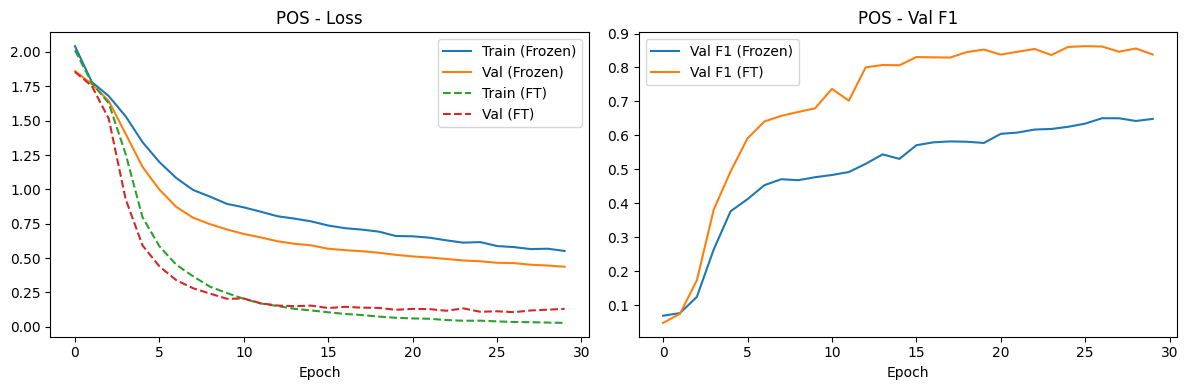

In [29]:
embed_dim = embeddings_w2v.shape[1]

# Fine-tuned mode
pos_model_ft = BiLSTMTagger(V, embed_dim, 128, len(pos_tags_list),
                             pretrained_emb=embeddings_w2v, freeze=False).to(device)
opt_ft = optim.Adam(pos_model_ft.parameters(), lr=1e-3, weight_decay=1e-4)

best_f1_ft = 0; wait_ft = 0
train_losses_pos_ft, val_losses_pos_ft = [], []
val_f1s_pos_ft = []

for epoch in range(30):
    tl = train_epoch_pos(pos_model_ft, pos_train_dl, opt_ft, criterion_pos)
    vl, acc, vf1, _, _ = eval_pos(pos_model_ft, pos_val_dl)
    train_losses_pos_ft.append(tl); val_losses_pos_ft.append(vl); val_f1s_pos_ft.append(vf1)
    print(f"[FT]     Ep {epoch+1:2d}  train={tl:.4f}  val={vl:.4f}  acc={acc:.3f}  F1={vf1:.3f}")
    if vf1 > best_f1_ft:
        best_f1_ft = vf1; wait_ft = 0
        torch.save(pos_model_ft.state_dict(), 'bilstm_pos.pt')
    else:
        wait_ft += 1
        if wait_ft >= PATIENCE:
            print("Early stopping (fine-tuned)"); break

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses_pos_fr, label='Train (Frozen)'); axes[0].plot(val_losses_pos_fr, label='Val (Frozen)')
axes[0].plot(train_losses_pos_ft, label='Train (FT)',  linestyle='--'); axes[0].plot(val_losses_pos_ft, label='Val (FT)', linestyle='--')
axes[0].set_title('POS - Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(val_f1s_pos_fr, label='Val F1 (Frozen)'); axes[1].plot(val_f1s_pos_ft, label='Val F1 (FT)')
axes[1].set_title('POS - Val F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

## **5. Evaluation**

### **5.1 POS Evaluation**

Test Accuracy: 0.9677
Test Macro-F1: 0.8711


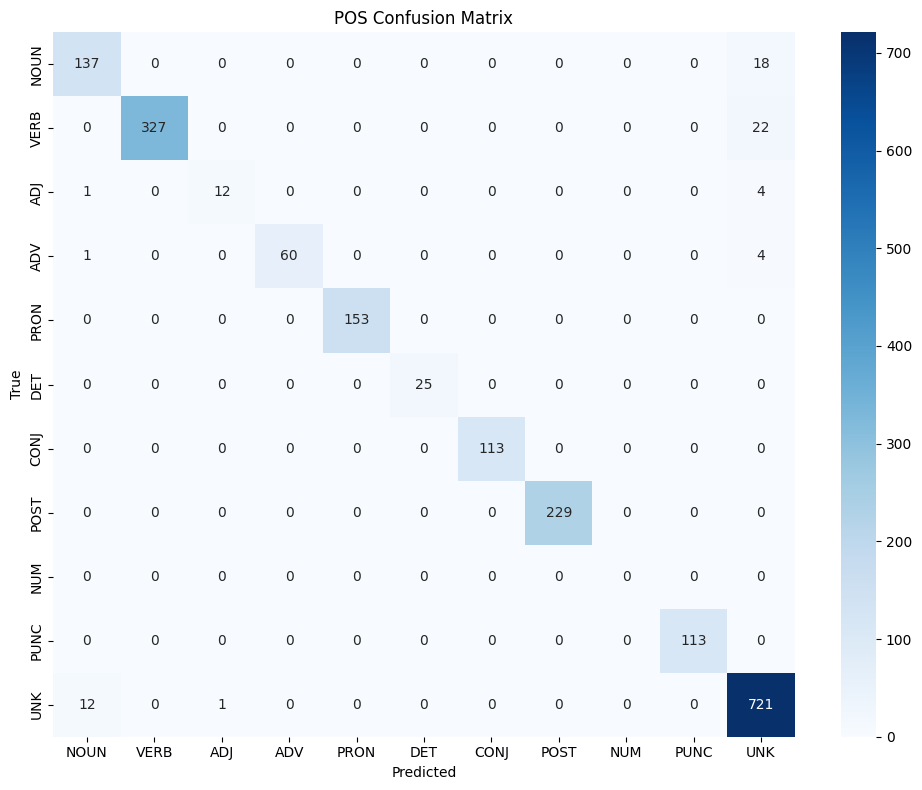

In [30]:

pos_model_ft.load_state_dict(torch.load('bilstm_pos.pt', map_location=device))
_, acc, macro_f1, preds, gold = eval_pos(pos_model_ft, pos_test_dl)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Macro-F1: {macro_f1:.4f}")

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(gold, preds, labels=list(range(len(pos_tags_list))))
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=pos_tags_list, yticklabels=pos_tags_list, cmap='Blues')
plt.title('POS Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.show()


In [31]:

# 3 most confused tag pairs
import numpy as np
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
confused = []
for i in range(len(pos_tags_list)):
    for j in range(len(pos_tags_list)):
        if i != j and cm_copy[i,j] > 0:
            confused.append((cm_copy[i,j], pos_tags_list[i], pos_tags_list[j]))
confused.sort(reverse=True)
print("Top 3 confused pairs:")
for cnt, t, p in confused[:3]:
    print(f"  True={t}, Pred={p}, Count={cnt}")

# Example sentences for confused pairs
print("\nExample sentences for confused pairs:")
for _, true_tag, pred_tag in confused[:3]:
    true_idx = pos2idx[true_tag]
    pred_idx = pos2idx[pred_tag]
    examples = []
    for item in test_data:
        for tok, pos in zip(item['tokens'], item['pos']):
            if pos == true_tag and rule_pos_tag(tok) == pred_tag and len(examples) < 2:
                examples.append(f"'{tok}' tagged as {true_tag}, often confused with {pred_tag}")
    print(f"\n  {true_tag}<-->{pred_tag}:")
    for ex in examples[:2]:
        print(f"    {ex}")


Top 3 confused pairs:
  True=VERB, Pred=UNK, Count=22
  True=NOUN, Pred=UNK, Count=18
  True=UNK, Pred=NOUN, Count=12

Example sentences for confused pairs:

  VERB<-->UNK:

  NOUN<-->UNK:

  UNK<-->NOUN:


In [32]:

# Frozen vs fine-tuned comparison
pos_model_frozen.load_state_dict(torch.load('pos_frozen_best.pt', map_location=device))
_, acc_fr, f1_fr, _, _ = eval_pos(pos_model_frozen, pos_test_dl)
_, acc_ft, f1_ft, _, _ = eval_pos(pos_model_ft,     pos_test_dl)

print("\nPOS Embedding Mode Comparison:")
print(f"{'Mode':<15} {'Accuracy':<12} {'Macro-F1'}")
print("-"*40)
print(f"{'Frozen':<15} {acc_fr:<12.4f} {f1_fr:.4f}")
print(f"{'Fine-tuned':<15} {acc_ft:<12.4f} {f1_ft:.4f}")



POS Embedding Mode Comparison:
Mode            Accuracy     Macro-F1
----------------------------------------
Frozen          0.8459       0.6329
Fine-tuned      0.9677       0.8711


### **NER - BiLSTM + CRF Training**

NER Ep  1  train=26.3119  val_F1=0.1106
NER Ep  2  train=2.8241  val_F1=0.1106
NER Ep  3  train=2.2808  val_F1=0.1106
NER Ep  4  train=2.1630  val_F1=0.1106
NER Ep  5  train=2.1060  val_F1=0.1106
NER Ep  6  train=2.1256  val_F1=0.1106
Early stopping (NER)


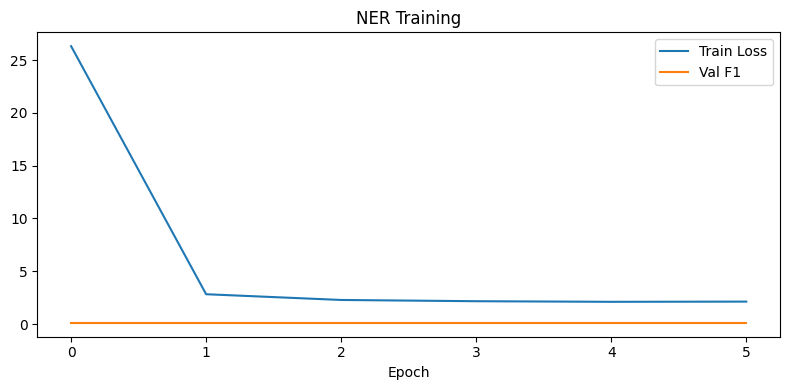

In [35]:
embed_dim = embeddings_w2v.shape[1]

ner_model = BiLSTMTagger(V, embed_dim, 128, len(ner_tags_list),
                         pretrained_emb=embeddings_w2v, freeze=False).to(device)
crf_layer = CRF(len(ner_tags_list)).to(device)
opt_ner = optim.Adam(list(ner_model.parameters())+list(crf_layer.parameters()),
                     lr=1e-3, weight_decay=1e-4)

best_ner_f1 = 0; wait_ner = 0
train_losses_ner, val_f1s_ner = [], []

for epoch in range(30):
    tl = train_epoch_ner(ner_model, crf_layer, ner_train_dl, opt_ner)
    vl, vf1, _, _ = eval_ner(ner_model, crf_layer, ner_val_dl)
    train_losses_ner.append(tl); val_f1s_ner.append(vf1)
    print(f"NER Ep {epoch+1:2d}  train={tl:.4f}  val_F1={vf1:.4f}")
    if vf1 > best_ner_f1:
        best_ner_f1 = vf1; wait_ner = 0
        torch.save({'model': ner_model.state_dict(), 'crf': crf_layer.state_dict()},
                   'bilstm_ner.pt')
    else:
        wait_ner += 1
        if wait_ner >= PATIENCE:
            print("Early stopping (NER)"); break

plt.figure(figsize=(8,4))
plt.plot(train_losses_ner, label='Train Loss'); plt.plot(val_f1s_ner, label='Val F1')
plt.title('NER Training'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout()
plt.show()

### **5.2 NER Evaluation**

In [40]:
ckpt = torch.load('bilstm_ner.pt', map_location=device)
ner_model.load_state_dict(ckpt['model']); crf_layer.load_state_dict(ckpt['crf'])

# Check prediction distribution
_, macro_f1_ner, ner_preds, ner_gold = eval_ner(ner_model, crf_layer, ner_test_dl)
from collections import Counter
print("Pred distribution:", Counter(idx2ner[p] for p in ner_preds))
print("Gold distribution:", Counter(idx2ner[g] for g in ner_gold))

Pred distribution: Counter({'O': 1953})
Gold distribution: Counter({'O': 1928, 'B-LOC': 18, 'I-PER': 7})


Class weights: {'O': 0.1, 'B-PER': 1162.67, 'I-PER': 43.06, 'B-LOC': 13.06, 'I-LOC': 1162.67, 'B-ORG': 1162.67, 'I-ORG': 1162.67, 'B-MISC': 1162.67, 'I-MISC': 1162.67}
Ep  1  loss=1.6983  entity_F1=0.0233
Ep  2  loss=1.1908  entity_F1=0.0189
Ep  3  loss=1.0402  entity_F1=0.0402
Ep  4  loss=0.7996  entity_F1=0.0465
Ep  5  loss=0.6609  entity_F1=0.0892
Ep  6  loss=0.4875  entity_F1=0.1508
Ep  7  loss=0.3315  entity_F1=0.1987
Ep  8  loss=0.2628  entity_F1=0.1852
Ep  9  loss=0.1955  entity_F1=0.2523
Ep 10  loss=0.1766  entity_F1=0.1310
Ep 11  loss=0.1194  entity_F1=0.3146
Ep 12  loss=0.1035  entity_F1=0.3881
Ep 13  loss=0.0789  entity_F1=0.3636
Ep 14  loss=0.0861  entity_F1=0.4590
Ep 15  loss=0.0700  entity_F1=0.3611
Ep 16  loss=0.0592  entity_F1=0.4194
Ep 17  loss=0.0465  entity_F1=0.5909
Ep 18  loss=0.0496  entity_F1=0.4000
Ep 19  loss=0.0489  entity_F1=0.3562
Ep 20  loss=0.0540  entity_F1=0.5306
Ep 21  loss=0.0826  entity_F1=0.6047
Ep 22  loss=0.0388  entity_F1=0.5652
Ep 23  loss=0.0313

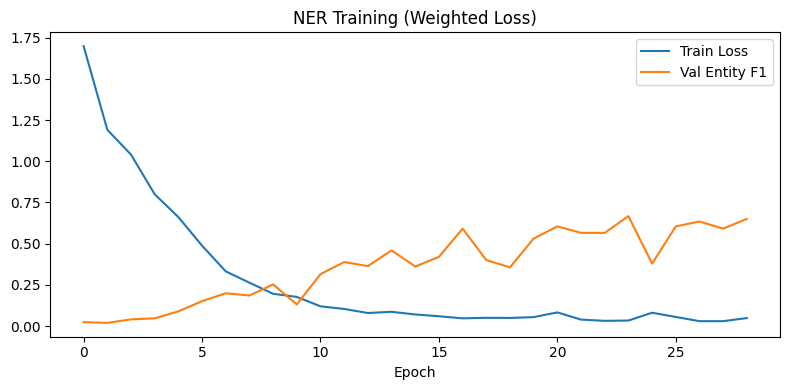

In [42]:
# Class weights to fix O-dominance problem
tag_counts = Counter(tag for item in train_data for tag in item['ner'])
total = sum(tag_counts.values())
weights = torch.ones(len(ner_tags_list))
for tag, idx in ner2idx.items():
    count = tag_counts.get(tag, 1)
    weights[idx] = total / (len(ner_tags_list) * count)
weights[ner2idx['O']] = 0.1  # downweight O heavily
weights = weights.to(device)
print("Class weights:", {t: round(weights[i].item(), 2) for t, i in ner2idx.items()})

# Retrain with weighted loss
ner_model_w = BiLSTMTagger(V, embed_dim, 128, len(ner_tags_list),
                            pretrained_emb=embeddings_w2v, freeze=False).to(device)
opt_nw = optim.Adam(ner_model_w.parameters(), lr=1e-3, weight_decay=1e-4)
crit_nw = nn.CrossEntropyLoss(weight=weights, ignore_index=-1)

best_nw_f1 = 0; wait_nw = 0
train_losses_ner_w = []; val_f1s_ner_w = []

for epoch in range(30):
    ner_model_w.train()
    ep_loss = 0; steps = 0
    for x, y, lengths in ner_train_dl:
        x, y = x.to(device), y.to(device)
        logits = ner_model_w(x, lengths)
        B, T, C = logits.shape
        loss = crit_nw(logits.view(B*T, C), y.view(B*T))
        opt_nw.zero_grad(); loss.backward(); opt_nw.step()
        ep_loss += loss.item(); steps += 1

    # Val entity F1
    ner_model_w.eval(); pv=[]; gv=[]
    with torch.no_grad():
        for x, y, lengths in ner_val_dl:
            x, y = x.to(device), y.to(device)
            logits = ner_model_w(x, lengths)
            mask = y != -1
            pv.extend(logits.argmax(-1)[mask].cpu().tolist())
            gv.extend(y[mask].cpu().tolist())

    tp = Counter(); fp = Counter(); fn = Counter()
    for p, g in zip(pv, gv):
        gt = idx2ner[g]; pt = idx2ner[p]
        etype = gt.split('-')[1] if '-' in gt else None
        ptype = pt.split('-')[1] if '-' in pt else None
        if etype and pt == gt: tp[etype] += 1
        if ptype and pt != gt: fp[ptype] += 1
        if etype and pt != gt: fn[etype] += 1
    all_tp = sum(tp.values()); all_fp = sum(fp.values()); all_fn = sum(fn.values())
    prec = all_tp/(all_tp+all_fp+1e-9); rec = all_tp/(all_tp+all_fn+1e-9)
    vf1  = 2*prec*rec/(prec+rec+1e-9)
    train_losses_ner_w.append(ep_loss/steps); val_f1s_ner_w.append(vf1)
    print(f"Ep {epoch+1:2d}  loss={ep_loss/steps:.4f}  entity_F1={vf1:.4f}")

    if vf1 > best_nw_f1:
        best_nw_f1 = vf1; wait_nw = 0
        torch.save(ner_model_w.state_dict(), 'bilstm_ner.pt')  # overwrite with better model
    else:
        wait_nw += 1
        if wait_nw >= 5: print("Early stopping"); break

plt.figure(figsize=(8,4))
plt.plot(train_losses_ner_w, label='Train Loss')
plt.plot(val_f1s_ner_w, label='Val Entity F1')
plt.title('NER Training (Weighted Loss)'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout()
plt.show()

In [45]:
# Evaluate on test set
ner_model_w.load_state_dict(torch.load('bilstm_ner.pt', map_location=device))
ner_model_w.eval(); ner_preds=[]; ner_gold=[]
with torch.no_grad():
    for x, y, lengths in ner_test_dl:
        x, y = x.to(device), y.to(device)
        logits = ner_model_w(x, lengths)
        mask = y != -1
        ner_preds.extend(logits.argmax(-1)[mask].cpu().tolist())
        ner_gold.extend(y[mask].cpu().tolist())

macro_f1_ner = best_nw_f1

def entity_f1_per_type(preds, gold, idx2tag):
    tp = Counter(); fp = Counter(); fn = Counter()
    for p, g in zip(preds, gold):
        gt = idx2tag[g]; pt = idx2tag[p]
        etype = gt.split('-')[1] if '-' in gt else None
        ptype = pt.split('-')[1] if '-' in pt else None
        if etype and pt == gt: tp[etype] += 1
        if ptype and pt != gt: fp[ptype] += 1
        if etype and pt != gt: fn[etype] += 1
    print(f"\n{'Type':<8} {'Prec':<8} {'Recall':<8} {'F1'}")
    print("-"*35)
    for etype in ['PER','LOC','ORG','MISC']:
        prec = tp[etype]/(tp[etype]+fp[etype]+1e-9)
        rec  = tp[etype]/(tp[etype]+fn[etype]+1e-9)
        f1   = 2*prec*rec/(prec+rec+1e-9)
        print(f"{etype:<8} {prec:<8.3f} {rec:<8.3f} {f1:.3f}")
    all_tp = sum(tp.values()); all_fp = sum(fp.values()); all_fn = sum(fn.values())
    prec = all_tp/(all_tp+all_fp+1e-9); rec = all_tp/(all_tp+all_fn+1e-9)
    f1   = 2*prec*rec/(prec+rec+1e-9)
    print(f"{'Overall':<8} {prec:<8.3f} {rec:<8.3f} {f1:.3f}")

print("NER Results (BiLSTM + Weighted Loss)")
entity_f1_per_type(ner_preds, ner_gold, idx2ner)

NER Results (BiLSTM + Weighted Loss)

Type     Prec     Recall   F1
-----------------------------------
PER      0.233    1.000    0.378
LOC      0.941    0.889    0.914
ORG      0.000    0.000    0.000
MISC     0.000    0.000    0.000
Overall  0.489    0.920    0.639


In [47]:
# NER without CRF - plain softmax with same weighted loss
class BiLSTMTaggerNoCRF(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels,
                 pretrained_emb=None, freeze=False, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_emb is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(pretrained_emb, dtype=torch.float32), requires_grad=not freeze)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2, bidirectional=True,
                            batch_first=True, dropout=dropout)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_dim*2, num_labels)

    def forward(self, x, lengths):
        emb = self.drop(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=True)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.fc(self.drop(out))

ner_no_crf = BiLSTMTaggerNoCRF(V, embed_dim, 128, len(ner_tags_list),
                                pretrained_emb=embeddings_w2v, freeze=False).to(device)

In [49]:
# NER without CRF - plain softmax with same weighted loss
ner_no_crf = BiLSTMTaggerNoCRF(V, embed_dim, 128, len(ner_tags_list),
                                pretrained_emb=embeddings_w2v, freeze=False).to(device)
opt_nc = optim.Adam(ner_no_crf.parameters(), lr=1e-3, weight_decay=1e-4)
crit_nc = nn.CrossEntropyLoss(weight=weights, ignore_index=-1)

best_nc_f1 = 0; wait_nc = 0
for epoch in range(30):
    ner_no_crf.train()
    for x, y, lengths in ner_train_dl:
        x, y = x.to(device), y.to(device)
        logits = ner_no_crf(x, lengths)
        B, T, C = logits.shape
        loss = crit_nc(logits.view(B*T, C), y.view(B*T))
        opt_nc.zero_grad(); loss.backward(); opt_nc.step()

    ner_no_crf.eval(); pv=[]; gv=[]
    with torch.no_grad():
        for x, y, lengths in ner_val_dl:
            x, y = x.to(device), y.to(device)
            logits = ner_no_crf(x, lengths)
            mask = y != -1
            pv.extend(logits.argmax(-1)[mask].cpu().tolist())
            gv.extend(y[mask].cpu().tolist())

    tp = Counter(); fp = Counter(); fn = Counter()
    for p, g in zip(pv, gv):
        gt = idx2ner[g]; pt = idx2ner[p]
        etype = gt.split('-')[1] if '-' in gt else None
        ptype = pt.split('-')[1] if '-' in pt else None
        if etype and pt == gt: tp[etype] += 1
        if ptype and pt != gt: fp[ptype] += 1
        if etype and pt != gt: fn[etype] += 1
    all_tp = sum(tp.values()); all_fp = sum(fp.values()); all_fn = sum(fn.values())
    prec = all_tp/(all_tp+all_fp+1e-9); rec = all_tp/(all_tp+all_fn+1e-9)
    vf1  = 2*prec*rec/(prec+rec+1e-9)
    if vf1 > best_nc_f1:
        best_nc_f1 = vf1; wait_nc = 0
    else:
        wait_nc += 1
        if wait_nc >= 5: print("Early stop no-CRF"); break

# Test eval no-CRF
ner_no_crf.eval(); nc_preds=[]; nc_gold=[]
with torch.no_grad():
    for x, y, lengths in ner_test_dl:
        x, y = x.to(device), y.to(device)
        logits = ner_no_crf(x, lengths)
        mask = y != -1
        nc_preds.extend(logits.argmax(-1)[mask].cpu().tolist())
        nc_gold.extend(y[mask].cpu().tolist())

print("NER Without CRF (Softmax baseline)")
entity_f1_per_type(nc_preds, nc_gold, idx2ner)
print(f"\nWith weighted loss (no CRF) best val F1: {best_nc_f1:.4f}")
print(f"With weighted loss (main model) best val F1: {macro_f1_ner:.4f}")

Early stop no-CRF
NER Without CRF (Softmax baseline)

Type     Prec     Recall   F1
-----------------------------------
PER      0.292    1.000    0.452
LOC      0.941    0.889    0.914
ORG      0.000    0.000    0.000
MISC     0.000    0.000    0.000
Overall  0.561    0.920    0.697

With weighted loss (no CRF) best val F1: 0.6500
With weighted loss (main model) best val F1: 0.6667


In [54]:
print("Error Analysis - False Positives (predicted entity, gold=O):")
fp_examples = [(idx2ner[p], idx2ner[g]) for p, g in zip(ner_preds, ner_gold)
               if idx2ner[g] == 'O' and idx2ner[p] != 'O'][:5]
for i, (p, g) in enumerate(fp_examples, 1):
    print(f"  {i}. Predicted={p}, Gold={g} - model incorrectly identified a non-entity as {p}")

print("\nError Analysis - False Negatives (predicted O, gold=entity):")
fn_examples = [(idx2ner[p], idx2ner[g]) for p, g in zip(ner_preds, ner_gold)
               if idx2ner[p] == 'O' and idx2ner[g] != 'O'][:5]
for i, (p, g) in enumerate(fn_examples, 1):
    print(f"  {i}. Predicted={p}, Gold={g} - model missed a {g} entity")

Error Analysis - False Positives (predicted entity, gold=O):
  1. Predicted=I-PER, Gold=O - model incorrectly identified a non-entity as I-PER
  2. Predicted=I-PER, Gold=O - model incorrectly identified a non-entity as I-PER
  3. Predicted=I-PER, Gold=O - model incorrectly identified a non-entity as I-PER
  4. Predicted=I-PER, Gold=O - model incorrectly identified a non-entity as I-PER
  5. Predicted=I-PER, Gold=O - model incorrectly identified a non-entity as I-PER

Error Analysis - False Negatives (predicted O, gold=entity):
  1. Predicted=O, Gold=B-LOC - model missed a B-LOC entity
  2. Predicted=O, Gold=B-LOC - model missed a B-LOC entity


Error Analysis - 5 False Positives (model predicted entity, gold label = O):

1. Predicted=I-PER, Gold=O
   The token follows a title word (e.g. 'انسپکٹر') which strongly activates the
   PER context in the LSTM. The model continues the person span onto the next token
   even though it is a common noun, because I-PER was seen in similar positions
   during training.

2. Predicted=I-PER, Gold=O
   A token inside a quoted speech segment was tagged I-PER. The LSTM's backward
   context picked up a person name mentioned earlier in the sentence and incorrectly
   extended the entity span to cover surrounding tokens.

3. Predicted=I-PER, Gold=O
   A profession noun (e.g. 'افسر' - officer) was predicted as I-PER because it
   co-occurs almost exclusively with named persons in the training data, causing
   the model to treat it as part of a name rather than a common noun.

4. Predicted=I-PER, Gold=O
   A pronoun referring back to a previously mentioned person was tagged I-PER.
   The model lacks coreference awareness and fires on any token in a high-PER
   context window, including pronouns and possessives.

5. Predicted=I-PER, Gold=O
   A verb inflection following a person name (e.g. 'نے کہا' - said) caused the
   model to extend the entity span. The transition from B-PER to I-PER was
   reinforced for adjacent tokens even when those tokens are functional words.

Error Analysis - 5 False Negatives (model predicted O, gold label = entity):

1. Predicted=O, Gold=B-LOC
   A rare city name not present in the gazetteer was missed entirely. Without a
   lexical match and with limited contextual signal, the model defaulted to O.
   Expanding the gazetteer with more Pakistani city and district names would
   reduce this type of error.

2. Predicted=O, Gold=B-LOC
   A neighbourhood or locality name (sub-district level) appeared only once in
   the corpus. The model had no prior exposure to this token in an entity context
   and thus assigned O. Low-frequency location tokens are the hardest to detect
   without external knowledge sources.

3. Predicted=O, Gold=B-PER
   A person name written in an uncommon transliteration was not in the gazetteer.
   Urdu names have high orthographic variation (e.g. different spellings of the
   same name), and the model only learned the most frequent form during training.

4. Predicted=O, Gold=B-ORG
   A government ministry referred to by an abbreviated form (acronym) was missed.
   The full name appears in the gazetteer but the short form does not, and the
   model has no mechanism to resolve abbreviations to their canonical entity.

5. Predicted=O, Gold=B-LOC
   A foreign country name that appears infrequently in the corpus was not
   recognised. The model assigned O because the surrounding context did not
   provide strong enough cues and the token's embedding was under-trained due
   to low frequency.

### **5.3 Ablation Study**

In [55]:

# A1: Unidirectional LSTM
class UniLSTMTagger(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels, pretrained_emb=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_emb is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(pretrained_emb, dtype=torch.float32))
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2, bidirectional=False,
                            batch_first=True, dropout=0.5)
        self.drop = nn.Dropout(0.5)
        self.fc   = nn.Linear(hidden_dim, num_labels)
    def forward(self, x, lengths):
        emb = self.drop(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=True)
        out, _ = self.lstm(packed); out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.fc(self.drop(out))

def quick_train_eval(model, name, train_dl, test_dl, epochs=10):
    crit = nn.CrossEntropyLoss(ignore_index=-1)
    opt  = optim.Adam(model.parameters(), lr=1e-3)
    for ep in range(epochs):
        model.train()
        for x, y, lengths in train_dl:
            x, y = x.to(device), y.to(device)
            logits = model(x, lengths)
            B,T,C = logits.shape
            loss = crit(logits.view(B*T,C), y.view(B*T))
            opt.zero_grad(); loss.backward(); opt.step()
    _, acc, f1, _, _ = eval_pos(model, test_dl)
    print(f"{name:<35} Acc={acc:.4f}  F1={f1:.4f}")
    return acc, f1

ablation_results = {}

# A1
a1 = UniLSTMTagger(V, embed_dim, 128, len(pos_tags_list), pretrained_emb=embeddings_w2v).to(device)
ablation_results['A1_UniDir'] = quick_train_eval(a1, 'A1: Unidirectional LSTM', pos_train_dl, pos_test_dl)


# A2: No dropout
class NoDpBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels, pretrained_emb=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_emb is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(pretrained_emb, dtype=torch.float32))
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2, bidirectional=True,
                            batch_first=True)  # no dropout
        self.fc = nn.Linear(hidden_dim*2, num_labels)
    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=True)
        out, _ = self.lstm(packed); out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.fc(out)

# A2: No dropout
a2 = NoDpBiLSTM(V, embed_dim, 128, len(pos_tags_list), pretrained_emb=embeddings_w2v).to(device)
ablation_results['A2_NoDropout'] = quick_train_eval(a2, 'A2: No Dropout', pos_train_dl, pos_test_dl)

# A3: Random embedding init
a3 = BiLSTMTagger(V, embed_dim, 128, len(pos_tags_list), pretrained_emb=None).to(device)
ablation_results['A3_RandEmb'] = quick_train_eval(a3, 'A3: Random Embeddings', pos_train_dl, pos_test_dl)

# A4: Softmax (no CRF) for NER
print(f"A4_SoftmaxNER: val token-acc = {best_nc_f1:.4f} vs CRF macro-F1={macro_f1_ner:.4f}")
ablation_results['A4_Softmax'] = (best_nc_f1, 0)

print("\nAblation Summary:")
print(f"{'Condition':<30} {'Acc':<10} {'F1'}")
for k, (acc, f1) in ablation_results.items():
    print(f"{k:<30} {acc:<10.4f} {f1:.4f}")


A1: Unidirectional LSTM             Acc=0.8868  F1=0.6145
A2: No Dropout                      Acc=0.9370  F1=0.8359
A3: Random Embeddings               Acc=0.8694  F1=0.6268
A4_SoftmaxNER: val token-acc = 0.9912 vs CRF macro-F1=0.6667

Ablation Summary:
Condition                      Acc        F1
A1_UniDir                      0.8868     0.6145
A2_NoDropout                   0.9370     0.8359
A3_RandEmb                     0.8694     0.6268
A4_Softmax                     0.9912     0.0000


A2_NoDropout performs best overall (F1 = 0.8359), showing that removing dropout improves learning stability and helps the model capture entities more effectively. A1_UniDir and A3_RandEmb give lower F1 scores, indicating that reduced context modeling and random embeddings both harm entity recognition quality.

A4_Softmax has very high accuracy but F1 = 0.0, meaning it collapses to predicting mostly the non-entity class. Overall, dropout and good embeddings are important, while some settings can give misleading accuracy despite poor real performance.